# Warehouse Robot Capacity Experiment

## Research Track II

### Research question

How does increasing robot carrying capacity from one to two packages affect
solvability, mission makespan, plan length, and planning complexity under
different package distributions and deadline constraints?

The experiment uses:

- a PDDL+ warehouse domain;
- ENHSP with the `opt-hrmax` planner;
- controlled scenarios with 2 or 3 packages;
- relaxed or tight deadlines;
- clustered or distributed package layouts;
- ROS2 for interactive experiment execution.


In [1]:
from pathlib import Path
import json
import threading
import time

import pandas as pd
import warnings

warnings.filterwarnings(
    "ignore",
    message="Unable to import Axes3D.*",
    category=UserWarning,
)

import matplotlib.pyplot as plt
import ipywidgets as widgets

from IPython.display import display, clear_output

import rclpy
from rclpy.node import Node
from std_msgs.msg import String

PROJECT_ROOT = Path.home() / "RT2_warehouse_research"
RESULTS_FILE = PROJECT_ROOT / "data/final/final_results.csv"

print("Environment loaded successfully.")


Environment loaded successfully.


## Final experimental dataset

The final factorial experiment contains 160 scenarios.

Every scenario is evaluated with both robot capacities:

- capacity 1;
- capacity 2.

This produces 320 planner runs in total.


In [2]:
df = pd.read_csv(RESULTS_FILE)

print("Total planner runs:", len(df))
print("Unique scenarios:", df["scenario_id"].nunique())
print()
print("Runs by capacity:")
print(df["capacity"].value_counts().sort_index())

display(df.head())


Total planner runs: 320
Unique scenarios: 160

Runs by capacity:
capacity
1    160
2    160
Name: count, dtype: int64


,scenario_id,capacity,seed,num_packages,deadline_mode,layout_mode,locations,deadlines,problem_file,status,timed_out,return_code,plan_length,makespan,metric_search,planning_time_ms,expanded_nodes,states_evaluated
0,1000,1,1,2,relaxed,clustered,aisle-A|aisle-A,26|21,scenario_1000_capacity1.pddl,solved,False,0,20.0,8.0,20.0,94.0,661,1180
1,1000,2,1,2,relaxed,clustered,aisle-A|aisle-A,26|21,scenario_1000_capacity2.pddl,solved,False,0,12.0,4.0,12.0,37.0,50,117
2,1001,1,2,2,relaxed,clustered,aisle-B|aisle-B,27|26,scenario_1001_capacity1.pddl,solved,False,0,24.0,12.0,24.0,138.0,1272,2148
3,1001,2,2,2,relaxed,clustered,aisle-B|aisle-B,27|26,scenario_1001_capacity2.pddl,solved,False,0,14.0,6.0,14.0,43.0,88,173
4,1002,1,3,2,relaxed,clustered,aisle-A|aisle-A,20|21,scenario_1002_capacity1.pddl,solved,False,0,20.0,8.0,20.0,103.0,661,1180


In [3]:
status_summary = pd.crosstab(
    df["capacity"],
    df["status"],
)

display(status_summary)

for capacity in [1, 2]:
    subset = df[df["capacity"] == capacity]

    success_rate = (
        subset["status"].eq("solved").mean() * 100
    )

    print(
        f"Capacity {capacity}: "
        f"{success_rate:.2f}% solved"
    )


status,solved,unsolvable
capacity,,
1,116,44
2,150,10


Capacity 1: 72.50% solved
Capacity 2: 93.75% solved


## ROS2 interactive experiment client

The notebook communicates with the ROS2 experiment node using two topics:

- `/warehouse_experiment/request`
- `/warehouse_experiment/result`

A request contains a scenario ID and robot capacity.  
The ROS2 node invokes ENHSP and publishes the resulting planning metrics.


In [4]:
class NotebookExperimentClient(Node):

    def __init__(self):
        super().__init__("warehouse_notebook_client")

        self.publisher = self.create_publisher(
            String,
            "/warehouse_experiment/request",
            10,
        )

        self.subscription = self.create_subscription(
            String,
            "/warehouse_experiment/result",
            self._result_callback,
            10,
        )

        self.last_result = None

    def _result_callback(self, message):
        self.last_result = json.loads(message.data)

    def run_experiment(
        self,
        scenario_id,
        capacity,
        timeout=130,
    ):
        self.last_result = None

        message = String()

        message.data = json.dumps(
            {
                "scenario_id": int(scenario_id),
                "capacity": int(capacity),
            }
        )

        self.publisher.publish(message)

        start_time = time.time()

        while self.last_result is None:

            rclpy.spin_once(
                self,
                timeout_sec=0.1,
            )

            if time.time() - start_time > timeout:
                return {
                    "scenario_id": int(scenario_id),
                    "capacity": int(capacity),
                    "status": "client_timeout",
                }

        return self.last_result


In [5]:
if not rclpy.ok():
    rclpy.init()

if "client" in globals():
    try:
        client.destroy_node()
    except Exception:
        pass

client = NotebookExperimentClient()

print("ROS2 notebook client ready.")


ROS2 notebook client ready.


## Run a live planning experiment

Select a scenario and carrying capacity, then press **Run experiment**.

The external `warehouse_experiment` ROS2 node must be running in Term 1.


In [6]:
scenario_selector = widgets.Dropdown(
    options=sorted(df["scenario_id"].unique()),
    value=1000,
    description="Scenario:",
)

capacity_selector = widgets.ToggleButtons(
    options=[1, 2],
    value=2,
    description="Capacity:",
)

run_button = widgets.Button(
    description="Run experiment",
    button_style="success",
)

output = widgets.Output()


def on_run_clicked(_):

    with output:
        clear_output()

        scenario_id = scenario_selector.value
        capacity = capacity_selector.value

        print(
            f"Running scenario {scenario_id}, "
            f"capacity {capacity}..."
        )

        result = client.run_experiment(
            scenario_id,
            capacity,
        )

        print()
        print(json.dumps(result, indent=2))


run_button.on_click(on_run_clicked)

display(
    scenario_selector,
    capacity_selector,
    run_button,
    output,
)


Dropdown(description='Scenario:', options=(1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1…

ToggleButtons(description='Capacity:', index=1, options=(1, 2), value=2)

Button(button_style='success', description='Run experiment', style=ButtonStyle())

Output()

## Success rate by experimental condition


In [7]:
plot_df = df.copy()

plot_df["solved"] = (
    plot_df["status"] == "solved"
)

success = (
    plot_df.groupby(
        [
            "num_packages",
            "deadline_mode",
            "layout_mode",
            "capacity",
        ]
    )["solved"]
    .mean()
    .mul(100)
    .reset_index(
        name="success_rate"
    )
)

display(success)


,num_packages,deadline_mode,layout_mode,capacity,success_rate
0,2,relaxed,clustered,1,100.0
1,2,relaxed,clustered,2,100.0
2,2,relaxed,distributed,1,100.0
3,2,relaxed,distributed,2,100.0
4,2,tight,clustered,1,45.0
5,2,tight,clustered,2,100.0
6,2,tight,distributed,1,50.0
7,2,tight,distributed,2,50.0
8,3,relaxed,clustered,1,100.0
9,3,relaxed,clustered,2,100.0


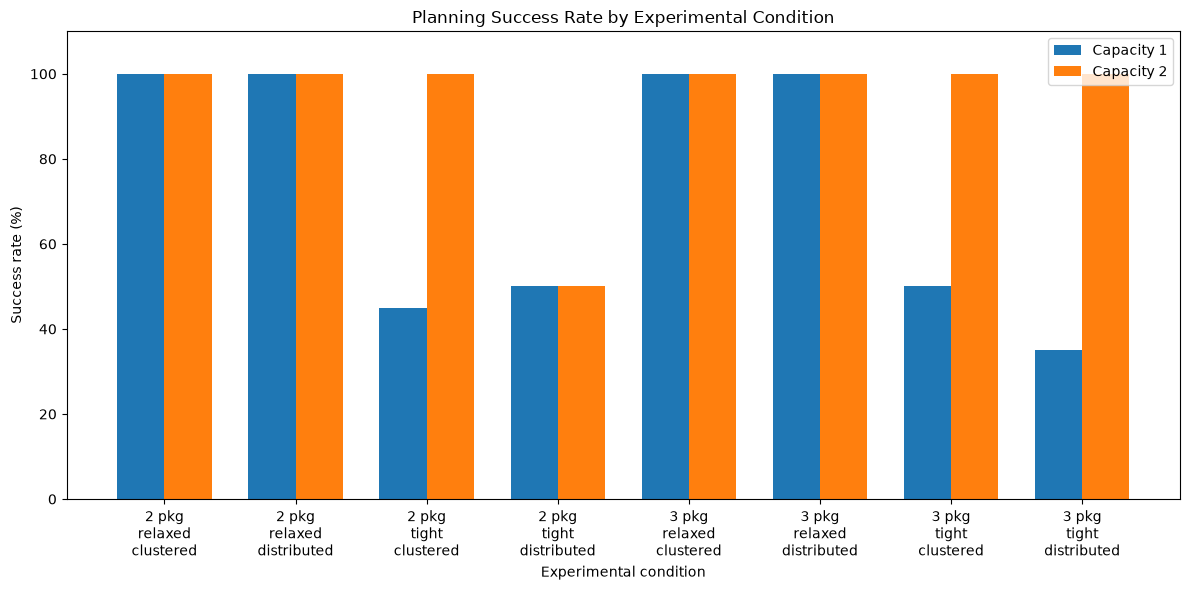

In [8]:
import numpy as np

success_pivot = success.pivot_table(
    index=[
        "num_packages",
        "deadline_mode",
        "layout_mode",
    ],
    columns="capacity",
    values="success_rate",
)

labels = [
    f"{packages} pkg\n{deadline}\n{layout}"
    for packages, deadline, layout
    in success_pivot.index
]

x = np.arange(len(labels))
width = 0.36

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.bar(
    x - width / 2,
    success_pivot[1].to_numpy(),
    width,
    label="Capacity 1",
)

ax.bar(
    x + width / 2,
    success_pivot[2].to_numpy(),
    width,
    label="Capacity 2",
)

ax.set_ylabel("Success rate (%)")

ax.set_xlabel(
    "Experimental condition"
)

ax.set_title(
    "Planning Success Rate by Experimental Condition"
)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.set_ylim(0, 110)

ax.legend()

plt.tight_layout()
plt.show()


In [9]:
import matplotlib

print("Matplotlib version:", matplotlib.__version__)
print("Backend:", matplotlib.get_backend())

Matplotlib version: 3.11.2
Backend: module://matplotlib_inline.backend_inline


## Paired makespan comparison

For mission-performance comparisons, only scenarios solved by both capacities
are used. This preserves the paired experimental design.


In [10]:
status = df.pivot(
    index="scenario_id",
    columns="capacity",
    values="status",
)

both_solved_ids = status.index[
    (status[1] == "solved")
    & (status[2] == "solved")
]

paired_runs = df[
    df["scenario_id"].isin(
        both_solved_ids
    )
]

makespan = paired_runs.pivot(
    index="scenario_id",
    columns="capacity",
    values="makespan",
)

makespan.columns = [
    "Capacity 1",
    "Capacity 2",
]

print(
    "Scenarios solved by both:",
    len(makespan),
)

display(makespan.describe())


Scenarios solved by both: 116


,Capacity 1,Capacity 2
count,116.000000,116.000000
mean,11.982759,8.500000
std,2.966429,2.472457
min,8.000000,4.000000
25%,10.000000,7.500000
50%,12.000000,10.000000
75%,14.000000,10.000000
max,18.000000,12.000000


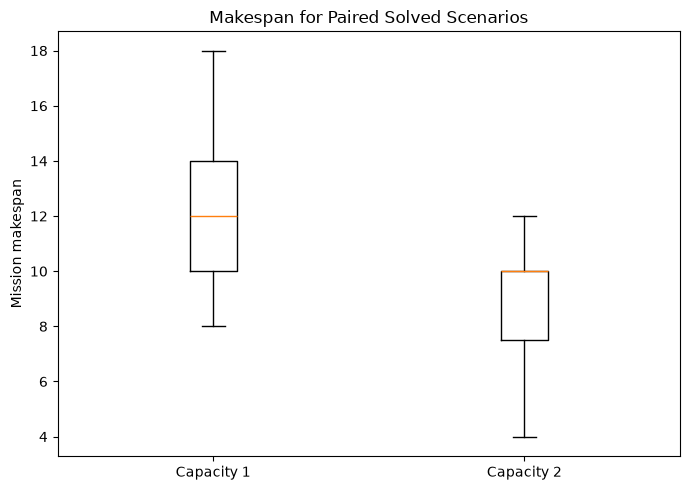

In [11]:
fig, ax = plt.subplots(
    figsize=(7, 5)
)

ax.boxplot(
    [
        makespan["Capacity 1"].dropna(),
        makespan["Capacity 2"].dropna(),
    ],
    tick_labels=[
        "Capacity 1",
        "Capacity 2",
    ],
)

ax.set_ylabel(
    "Mission makespan"
)

ax.set_title(
    "Makespan for Paired Solved Scenarios"
)

plt.tight_layout()
plt.show()


## Main experimental findings

Across the 160 paired scenarios:

- capacity 1 solved **116/160 (72.50%)**;
- capacity 2 solved **150/160 (93.75%)**;
- capacity 2 solved 34 scenarios that capacity 1 could not solve;
- there were no scenarios solved by capacity 1 but not by capacity 2.

Among the 116 scenarios solved by both capacities:

- mean makespan reduction: **28.54%**;
- mean plan-length reduction: **23.34%**;
- mean expanded-node reduction: **61.93%**;
- mean evaluated-state reduction: **57.80%**.

The experimental results indicate that additional carrying capacity is most
useful when the spatial distribution of packages allows the robot to transport
multiple packages during the same route.


## Statistical hypothesis testing

Because the same warehouse scenarios are evaluated under both robot
capacities, the experiment uses paired statistical tests.

For solvability, an exact McNemar test evaluates whether the probability of
solving a scenario differs between capacity 1 and capacity 2.

For quantitative planner metrics, only scenarios solved by both capacities
are compared. A Wilcoxon signed-rank test is used because the search metrics
are strongly non-normal and contain large differences in scale.


In [12]:
from scipy.stats import binomtest, wilcoxon

status_pairs = df.pivot(
    index="scenario_id",
    columns="capacity",
    values="status",
)

cap1_solved = status_pairs[1].eq("solved")
cap2_solved = status_pairs[2].eq("solved")

both_solved = (cap1_solved & cap2_solved).sum()
cap1_only = (cap1_solved & ~cap2_solved).sum()
cap2_only = (~cap1_solved & cap2_solved).sum()
neither = (~cap1_solved & ~cap2_solved).sum()

discordant = cap1_only + cap2_only

mcnemar = binomtest(
    min(cap1_only, cap2_only),
    n=discordant,
    p=0.5,
    alternative="two-sided",
)

print("Paired solvability results")
print("--------------------------")
print("Both solved:", both_solved)
print("Capacity 1 only:", cap1_only)
print("Capacity 2 only:", cap2_only)
print("Neither solved:", neither)
print()
print("Exact McNemar p-value:", mcnemar.pvalue)


Paired solvability results
--------------------------
Both solved: 116
Capacity 1 only: 0
Capacity 2 only: 34
Neither solved: 10

Exact McNemar p-value: 1.1641532182693481e-10


In [13]:
metrics = [
    "makespan",
    "plan_length",
    "expanded_nodes",
    "states_evaluated",
    "planning_time_ms",
]

cap1 = (
    paired_runs[paired_runs["capacity"] == 1]
    .set_index("scenario_id")
)

cap2 = (
    paired_runs[paired_runs["capacity"] == 2]
    .set_index("scenario_id")
)

rows = []

for metric in metrics:

    x = cap1[metric]
    y = cap2[metric]

    valid = x.notna() & y.notna()

    x = x[valid]
    y = y[valid]

    test = wilcoxon(
        x,
        y,
        alternative="two-sided",
    )

    reduction = (
        ((x - y) / x) * 100
    ).mean()

    rows.append(
        {
            "metric": metric,
            "paired_n": len(x),
            "capacity_1_mean": x.mean(),
            "capacity_2_mean": y.mean(),
            "mean_reduction_percent": reduction,
            "wilcoxon_p": test.pvalue,
        }
    )

statistical_results = pd.DataFrame(rows)

display(statistical_results)


,metric,paired_n,capacity_1_mean,capacity_2_mean,mean_reduction_percent,wilcoxon_p
0,makespan,116,11.982759,8.500000,28.540640,4.894180e-17
1,plan_length,116,26.931034,20.482759,23.335305,4.894180e-17
2,expanded_nodes,116,12395.594828,2544.370690,61.929044,2.406125e-20
3,states_evaluated,116,21328.577586,5401.439655,57.797306,2.930614e-20
4,planning_time_ms,114,602.903509,258.921053,44.266429,1.750499e-18


### Interpretation

The paired analysis separates two distinct effects:

1. **Feasibility:** whether a valid deadline-respecting plan exists.
2. **Efficiency:** how costly the resulting planning problem and mission are
   when both capacities can solve the same scenario.

This distinction is important because capacity 2 solves additional scenarios
that capacity 1 cannot solve; those scenarios cannot be meaningfully compared
using makespan or plan length.
